# Financial Networks for Portfolio Construction

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t`

This notebook demonstrates using **network theory** for portfolio construction
and risk diagnostics. It forms the investable universe and estimates the
correlation network before a separate evaluation window.

**Learning Objectives**:
- Build correlation networks and extract minimum spanning trees from real price data
- Compute centrality metrics that describe MST structure
- Construct network-diversified portfolios that underweight central nodes
- Run a stylized, order-independent shock-propagation sensitivity

**Book Reference**: Chapter 23, Section 23.5 (Financial Networks: From Correlations to Portfolios)

**Prerequisites**: Familiarity with correlation matrices and portfolio construction.
Requires the US equities dataset (3,199 current and delisted securities).

Based on: Konstantinov et al. (2023) - Financial Networks

In [1]:
"""Financial networks for portfolio construction and shock-sensitivity analysis."""

from __future__ import annotations

import warnings
from logging import getLogger

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from scipy.sparse.csgraph import minimum_spanning_tree

from data import load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis, ml4t_palette

In [2]:
# Production defaults - Papermill overrides for testing
N_ASSETS = 100
ESTIMATION_DAYS = 504
EVALUATION_DAYS = 252
SEED = 42

In [3]:
set_global_seeds(SEED)
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
getLogger("matplotlib.font_manager").setLevel("ERROR")

## 1. Configuration

In [4]:
# Configuration
MIN_DATE = "2015-01-01"

print(f"Assets: {N_ASSETS}")
print(f"Estimation days: {ESTIMATION_DAYS}")
print(f"Evaluation days: {EVALUATION_DAYS}")
print(f"Min date: {MIN_DATE}")

Assets: 100
Estimation days: 504
Evaluation days: 252
Min date: 2015-01-01


## 2. Load Real Market Data

Load US equities, define a broad-market calendar, and form the universe from
the estimation window only.

In [5]:
# The canonical loader returns `symbol` and `timestamp`.
df = load_us_equities(start_date=MIN_DATE)
df = df.with_columns((pl.col("adj_close") * pl.col("adj_volume")).alias("dollar_volume"))

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Unique symbols: {df['symbol'].n_unique()}")

Loaded 2,224,952 rows
Date range: 2015-01-02 to 2018-03-27
Unique symbols: 3097


In [6]:
# A handful of provider rows fall on non-market dates. Requiring broad coverage
# removes those rows without consulting future returns for universe membership.
market_dates = (
    df.group_by("timestamp")
    .agg(pl.col("symbol").n_unique().alias("symbols_observed"))
    .filter(pl.col("symbols_observed") >= 1_000)
    .sort("timestamp")["timestamp"]
)
required_dates = ESTIMATION_DAYS + EVALUATION_DAYS
if len(market_dates) < required_dates + 1:
    raise ValueError(f"Need {required_dates + 1} broad-market dates, found {len(market_dates)}")

return_dates = market_dates.tail(required_dates + 1)
analysis_dates = return_dates.tail(required_dates)
estimation_dates = analysis_dates.head(ESTIMATION_DAYS)
evaluation_dates = analysis_dates.tail(EVALUATION_DAYS)
estimation_start, estimation_end = estimation_dates.min(), estimation_dates.max()
evaluation_start, evaluation_end = evaluation_dates.min(), evaluation_dates.max()

print(f"Estimation: {estimation_start} to {estimation_end}")
print(f"Evaluation: {evaluation_start} to {evaluation_end}")

Estimation: 2015-03-26 to 2017-03-24
Evaluation: 2017-03-27 to 2018-03-27


In [7]:
# Rank only observations available by the estimation boundary. Requiring a
# complete estimation history is an ex-ante eligibility rule.
avg_dollar_volume = (
    df.filter(pl.col("timestamp").is_in(estimation_dates.implode()))
    .group_by("symbol")
    .agg(pl.col("dollar_volume").mean().alias("avg_dv"), pl.len().alias("n_obs"))
    .filter(pl.col("n_obs") == ESTIMATION_DAYS)
    .sort(["avg_dv", "symbol"], descending=[True, False])
    .head(N_ASSETS)
)
if avg_dollar_volume.height != N_ASSETS:
    raise ValueError(f"Need {N_ASSETS} eligible symbols, found {avg_dollar_volume.height}")

selected_symbols = avg_dollar_volume["symbol"].to_list()
df_filtered = df.filter(
    pl.col("symbol").is_in(selected_symbols) & pl.col("timestamp").is_in(return_dates.implode())
)

print(f"\nSelected {len(selected_symbols)} symbols using estimation-only dollar volume")
print(f"Sample symbols: {selected_symbols[:10]}")


Selected 100 symbols using estimation-only dollar volume
Sample symbols: ['AAPL', 'FB', 'AMZN', 'MSFT', 'BAC', 'NFLX', 'GOOGL', 'GOOG', 'GE', 'JPM']


## 3. Compute Returns and Correlation Network

Pairwise return correlations are mapped to a distance metric
$$d_{ij}=\sqrt{2\,(1-\rho_{ij})}$$
which lies in $[0, 2]$ and satisfies the triangle inequality, so the minimum
spanning tree built from these distances is well defined.

In [8]:
# Compute daily returns before splitting the windows.
df_filtered = df_filtered.sort(["symbol", "timestamp"])
df_filtered = df_filtered.with_columns(
    (pl.col("adj_close") / pl.col("adj_close").shift(1).over("symbol") - 1).alias("returns")
)

# Pivot to a fixed, estimation-formed column order.
returns_wide = (
    df_filtered.pivot(
        on="symbol",
        index="timestamp",
        values="returns",
    )
    .select(["timestamp", *selected_symbols])
    .sort("timestamp")
)

# The fixed universe can contain later symbol exits or isolated missing quotes.
# A zero return holds the marked value constant for that date. The diagnostic
# below makes this simplifying cash/stale-mark assumption explicit.
missing_by_window = returns_wide.select(pl.exclude("timestamp").is_null().sum()).sum_horizontal()[0]
evaluation_missing = (
    returns_wide.filter(pl.col("timestamp").is_in(evaluation_dates.implode()))
    .select(pl.exclude("timestamp").is_null().sum())
    .sum_horizontal()[0]
)
returns_wide = returns_wide.fill_null(0.0)

estimation_frame = returns_wide.filter(pl.col("timestamp").is_in(estimation_dates.implode()))
evaluation_frame = returns_wide.filter(pl.col("timestamp").is_in(evaluation_dates.implode()))
estimation_returns = estimation_frame.drop("timestamp").to_numpy()
evaluation_returns = evaluation_frame.drop("timestamp").to_numpy()
evaluation_index = evaluation_frame["timestamp"].to_list()

asset_names = selected_symbols
n_assets = len(asset_names)

print(f"Estimation returns: {estimation_returns.shape}")
print(f"Evaluation returns: {evaluation_returns.shape}")
print(f"Missing symbol-date returns set to 0: {missing_by_window}")
print(f"Missing returns within evaluation: {evaluation_missing}")
print(f"Sample symbols: {asset_names[:5]}")

Estimation returns: (504, 100)
Evaluation returns: (252, 100)
Missing symbol-date returns set to 0: 547
Missing returns within evaluation: 447
Sample symbols: ['AAPL', 'FB', 'AMZN', 'MSFT', 'BAC']


In [9]:
assert estimation_returns.shape == (ESTIMATION_DAYS, N_ASSETS)
assert evaluation_returns.shape == (EVALUATION_DAYS, N_ASSETS)
assert np.isfinite(estimation_returns).all()
assert np.isfinite(evaluation_returns).all()
assert estimation_end < evaluation_start

In [10]:
# Calculate the correlation matrix on estimation returns only.
corr_matrix = np.corrcoef(estimation_returns.T)

# Map correlations to MST distances (formula in the markdown above).
distance_matrix = np.sqrt(2 * (1 - np.clip(corr_matrix, -1, 1)))
np.fill_diagonal(distance_matrix, 0)

print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Correlation range: [{corr_matrix.min():.3f}, {corr_matrix.max():.3f}]")
print(f"Distance range: [{distance_matrix.min():.3f}, {distance_matrix.max():.3f}]")

# Analyze correlation structure
corr_values = corr_matrix[np.triu_indices(n_assets, k=1)]
print(f"\nAverage correlation: {corr_values.mean():.3f}")
print(f"Median correlation: {np.median(corr_values):.3f}")

Correlation matrix shape: (100, 100)
Correlation range: [0.012, 1.000]
Distance range: [0.000, 1.406]

Average correlation: 0.335
Median correlation: 0.328


## 4. Minimum Spanning Tree

Extract hierarchical structure from the correlation network.

In [11]:
def compute_mst(distance_matrix: np.ndarray) -> tuple[np.ndarray, list]:
    """Compute minimum spanning tree from distance matrix."""
    # scipy.sparse.csgraph.minimum_spanning_tree
    mst = minimum_spanning_tree(distance_matrix).toarray()

    # Make symmetric
    mst = mst + mst.T

    # Extract edges
    edges = []
    for i in range(len(mst)):
        for j in range(i + 1, len(mst)):
            if mst[i, j] > 0:
                edges.append((i, j, mst[i, j]))

    return mst, edges

In [12]:
mst_matrix, mst_edges = compute_mst(distance_matrix)

print(f"MST edges: {len(mst_edges)}")
print(f"Expected edges (N-1): {n_assets - 1}")

# Verify MST properties
total_distance = sum(e[2] for e in mst_edges)
print(f"Total MST distance: {total_distance:.3f}")

# Show some MST connections (most correlated pairs)
sorted_edges = sorted(mst_edges, key=lambda e: e[2])
print("\nMost connected pairs (lowest distance = highest correlation):")
for i, j, d in sorted_edges[:5]:
    rho = 1 - d**2 / 2  # Convert back to correlation
    print(f"  {asset_names[i]} - {asset_names[j]}: ρ={rho:.3f}")

MST edges: 99
Expected edges (N-1): 99
Total MST distance: 85.262

Most connected pairs (lowest distance = highest correlation):
  GOOGL - GOOG: ρ=0.988
  BAC - C: ρ=0.913
  JPM - C: ρ=0.908
  GS - MS: ρ=0.900
  C - MS: ρ=0.884


## 5. Network Centrality Metrics

Calculate centrality measures that describe estimated MST structure.

### Degree Centrality

Counts the fraction of nodes each asset is connected to. High-degree nodes
are structural hubs in this estimated correlation tree.

In [13]:
def compute_degree_centrality(adjacency: np.ndarray) -> np.ndarray:
    """Compute degree centrality (normalized)."""
    binary_adj = (adjacency > 0).astype(float)
    degrees = binary_adj.sum(axis=1)
    return degrees / (len(degrees) - 1)

### Betweenness Centrality

The fraction of MST shortest paths that pass through each node. Bridge nodes
connecting otherwise separate clusters score highest. Computed on the MST with
edge distances via NetworkX.

In [14]:
def build_mst_graph(mst_matrix: np.ndarray, n: int) -> nx.Graph:
    """Build a weighted NetworkX graph from the symmetric MST distance matrix."""
    graph = nx.Graph()
    graph.add_nodes_from(range(n))
    for i in range(len(mst_matrix)):
        for j in range(i + 1, len(mst_matrix)):
            if mst_matrix[i, j] > 0:
                graph.add_edge(i, j, weight=mst_matrix[i, j])
    return graph

### Closeness Centrality

Inverse of the average MST shortest-path distance to all other nodes. Assets
near the tree center have short correlation-distance paths to other assets.

In [15]:
# Degree centrality on the MST adjacency; betweenness and closeness via NetworkX
# shortest paths using the MST edge distances.
mst_graph = build_mst_graph(mst_matrix, n_assets)
degree_centrality = compute_degree_centrality(mst_matrix)
betweenness_dict = nx.betweenness_centrality(mst_graph, weight="weight")
closeness_dict = nx.closeness_centrality(mst_graph, distance="weight")
betweenness_centrality = np.array([betweenness_dict[i] for i in range(n_assets)])
closeness_centrality = np.array([closeness_dict[i] for i in range(n_assets)])

# Create centrality DataFrame
centrality_df = pl.DataFrame(
    {
        "symbol": asset_names,
        "degree": degree_centrality,
        "betweenness": betweenness_centrality,
        "closeness": closeness_centrality,
    }
)

print("TOP 10 ASSETS BY CENTRALITY (MST)")

# Sort by composite score
centrality_df = centrality_df.with_columns(
    ((pl.col("degree") + pl.col("betweenness") + pl.col("closeness")) / 3).alias("composite")
)

top_central = centrality_df.sort("composite", descending=True).head(10)
print(top_central)

TOP 10 ASSETS BY CENTRALITY (MST)


shape: (10, 5)
┌────────┬──────────┬─────────────┬───────────┬───────────┐
│ symbol ┆ degree   ┆ betweenness ┆ closeness ┆ composite │
│ ---    ┆ ---      ┆ ---         ┆ ---       ┆ ---       │
│ str    ┆ f64      ┆ f64         ┆ f64       ┆ f64       │
╞════════╪══════════╪═════════════╪═══════════╪═══════════╡
│ BRK_B  ┆ 0.141414 ┆ 0.813441    ┆ 0.356558  ┆ 0.437138  │
│ C      ┆ 0.060606 ┆ 0.470831    ┆ 0.313215  ┆ 0.281551  │
│ JPM    ┆ 0.040404 ┆ 0.461967    ┆ 0.330275  ┆ 0.277548  │
│ MA     ┆ 0.060606 ┆ 0.350031    ┆ 0.271297  ┆ 0.227311  │
│ JNJ    ┆ 0.030303 ┆ 0.317048    ┆ 0.29977   ┆ 0.215707  │
│ AMGN   ┆ 0.070707 ┆ 0.310039    ┆ 0.254391  ┆ 0.211712  │
│ PEP    ┆ 0.070707 ┆ 0.191713    ┆ 0.282335  ┆ 0.181585  │
│ XOM    ┆ 0.020202 ┆ 0.199546    ┆ 0.285384  ┆ 0.168377  │
│ MSFT   ┆ 0.030303 ┆ 0.205318    ┆ 0.229405  ┆ 0.155009  │
│ CVX    ┆ 0.020202 ┆ 0.183467    ┆ 0.249662  ┆ 0.151111  │
└────────┴──────────┴─────────────┴───────────┴───────────┘


**Interpretation**: High-centrality assets are hubs in the estimated MST.
Centrality describes correlation-network structure; it does not establish
causal influence or systemic importance.

## 6. Network-Based Portfolio Construction

Use centrality metrics to construct diversified portfolios.

### Network-Diversified Weights

Inverse centrality weighting: underweight estimated MST hubs.

In [16]:
def project_capped_weights(raw_weights: np.ndarray, max_weight: float) -> np.ndarray:
    """Project nonnegative scores to sum to one without violating a weight cap."""
    if max_weight <= 0 or max_weight * len(raw_weights) < 1:
        raise ValueError("max_weight is infeasible for this portfolio size")
    scores = np.asarray(raw_weights, dtype=float)
    if (scores < 0).any() or not np.isfinite(scores).all() or scores.sum() <= 0:
        raise ValueError("raw_weights must be finite, nonnegative, and nonzero")

    weights = np.zeros_like(scores)
    free = np.ones(len(scores), dtype=bool)
    remaining = 1.0
    while free.any():
        free_scores = scores[free]
        if free_scores.sum() > 0:
            proposal = free_scores / free_scores.sum() * remaining
        else:
            proposal = np.full(free.sum(), remaining / free.sum())
        capped = proposal > max_weight
        if not capped.any():
            weights[free] = proposal
            break
        free_idx = np.flatnonzero(free)
        weights[free_idx[capped]] = max_weight
        free[free_idx[capped]] = False
        remaining = 1.0 - weights.sum()
    return weights

The portfolio rule converts inverse centrality scores into feasible weights
with the capped-simplex projection above.

In [17]:
def network_diversified_weights(
    centrality: np.ndarray,
    max_weight: float = 0.10,
) -> np.ndarray:
    """
    Construct portfolio weights using inverse centrality.

    High-centrality assets are estimated MST hubs, so the rule
    underweights them by construction.
    """
    inverse_cent = 1 / (centrality + 0.01)
    return project_capped_weights(inverse_cent, max_weight)

### Benchmark Portfolios

Equal weight and inverse-volatility as baselines for comparison.

In [18]:
def equal_weight_portfolio(n: int) -> np.ndarray:
    """Simple equal weight portfolio."""
    return np.ones(n) / n

### Inverse-Volatility Weights

Weight each asset by the inverse of its volatility - a simple risk-based
benchmark. (A constrained minimum-variance optimizer would also use the full
covariance structure; this notebook uses the lighter inverse-volatility rule.)

In [19]:
def inverse_volatility_weights(returns: np.ndarray, max_weight: float = 0.10) -> np.ndarray:
    """Weight assets by inverse estimation-window volatility."""
    cov = np.cov(returns.T)
    vols = np.sqrt(np.diag(cov))
    inv_vol = 1 / (vols + 1e-8)
    return project_capped_weights(inv_vol, max_weight)

In [20]:
# Construct different portfolios
w_equal = equal_weight_portfolio(n_assets)
w_inv_vol = inverse_volatility_weights(estimation_returns)
w_network_div = network_diversified_weights(degree_centrality, max_weight=0.10)

# Portfolio statistics
portfolios = {
    "Equal Weight": w_equal,
    "Inverse Volatility": w_inv_vol,
    "Network Diversified": w_network_div,
}

print("PORTFOLIO CONCENTRATION ANALYSIS")

PORTFOLIO CONCENTRATION ANALYSIS


In [21]:
concentration_rows = []
for name, weights in portfolios.items():
    hhi = np.sum(weights**2)
    effective_n = 1 / hhi
    max_weight = weights.max()
    concentration_rows.append(
        {
            "portfolio": name,
            "hhi": hhi,
            "effective_names": effective_n,
            "max_weight": max_weight,
        }
    )
    assert np.isclose(weights.sum(), 1.0)
    assert weights.min() >= 0
    assert weights.max() <= 0.10 + 1e-12

concentration = pl.DataFrame(concentration_rows)
print(concentration)

shape: (3, 4)
┌─────────────────────┬──────────┬─────────────────┬────────────┐
│ portfolio           ┆ hhi      ┆ effective_names ┆ max_weight │
│ ---                 ┆ ---      ┆ ---             ┆ ---        │
│ str                 ┆ f64      ┆ f64             ┆ f64        │
╞═════════════════════╪══════════╪═════════════════╪════════════╡
│ Equal Weight        ┆ 0.01     ┆ 100.0           ┆ 0.01       │
│ Inverse Volatility  ┆ 0.010934 ┆ 91.457358       ┆ 0.017528   │
│ Network Diversified ┆ 0.01096  ┆ 91.244282       ┆ 0.012597   │
└─────────────────────┴──────────┴─────────────────┴────────────┘


### Concentration Finding

The result is computed from the fixed weights rather than embedded as a
number that can drift after the universe changes.

In [22]:
network_concentration = concentration.filter(pl.col("portfolio") == "Network Diversified").row(
    0, named=True
)
equal_concentration = concentration.filter(pl.col("portfolio") == "Equal Weight").row(0, named=True)
display(
    Markdown(
        f"**Finding:** Network diversification produces "
        f"{network_concentration['effective_names']:.1f} effective names versus "
        f"{equal_concentration['effective_names']:.1f} for equal weight; its largest position is "
        f"{network_concentration['max_weight']:.1%}."
    )
)

**Finding:** Network diversification produces 91.2 effective names versus 100.0 for equal weight; its largest position is 1.3%.

The concentration table is determined entirely by weights fixed at the
estimation boundary. HHI and effective-name count show whether inverse
centrality actually disperses capital more evenly than equal weighting.

## 7. Stylized Shock-Propagation Sensitivity

This deterministic exercise diffuses a shock across correlations above a
threshold. It is not a causal contagion model or an estimate of portfolio loss.

In [23]:
def simulate_shock_diffusion(
    corr_matrix: np.ndarray,
    shock_asset: int,
    shock_magnitude: float = -0.10,
    contagion_threshold: float = 0.5,
    attenuation: float = 0.5,
    max_rounds: int = 5,
) -> dict:
    """Diffuse a shock synchronously through a thresholded correlation graph."""
    n = len(corr_matrix)
    impacted = np.zeros(n, dtype=bool)
    impacts = np.zeros(n)
    impacted[shock_asset] = True
    impacts[shock_asset] = shock_magnitude
    frontier = np.array([shock_asset])
    rounds = 0

    while len(frontier) and rounds < max_rounds:
        proposals = np.zeros(n)
        for source in frontier:
            eligible = (~impacted) & (corr_matrix[source] > contagion_threshold)
            propagated = impacts[source] * corr_matrix[source] * attenuation
            proposals[eligible] = np.minimum(proposals[eligible], propagated[eligible])
        frontier = np.flatnonzero(proposals < 0)
        impacts[frontier] = proposals[frontier]
        impacted[frontier] = True
        rounds += 1

    return {
        "shocked_asset": shock_asset,
        "n_impacted": int(impacted.sum()),
        "impacts": impacts,
        "propagation_rounds": rounds,
    }

In [24]:
# Compare shocks from high- and low-degree MST nodes.
print("STYLIZED SHOCK-DIFFUSION SENSITIVITY")

# Find highest and lowest centrality assets. argmin runs over positive-degree
# nodes only, then maps back to the original asset index.
high_central_idx = int(np.argmax(degree_centrality))
positive_degree_idx = np.where(degree_centrality > 0)[0]
low_central_idx = int(positive_degree_idx[np.argmin(degree_centrality[positive_degree_idx])])

scenarios = [
    ("High centrality shock", high_central_idx),
    ("Low centrality shock", low_central_idx),
]

shock_rows = []
for name, idx in scenarios:
    result = simulate_shock_diffusion(corr_matrix, idx)
    shock_rows.append(
        {
            "scenario": name,
            "symbol": asset_names[idx],
            "assets_reached": result["n_impacted"],
            "rounds": result["propagation_rounds"],
            "equal_weight_sensitivity": float(result["impacts"] @ w_equal),
            "network_weight_sensitivity": float(result["impacts"] @ w_network_div),
        }
    )

shock_summary = pl.DataFrame(shock_rows)
print(shock_summary)

STYLIZED SHOCK-DIFFUSION SENSITIVITY
shape: (2, 6)
┌─────────────────┬────────┬────────────────┬────────┬──────────────────────┬──────────────────────┐
│ scenario        ┆ symbol ┆ assets_reached ┆ rounds ┆ equal_weight_sensiti ┆ network_weight_sensi │
│ ---             ┆ ---    ┆ ---            ┆ ---    ┆ vity                 ┆ tivity               │
│ str             ┆ str    ┆ i64            ┆ i64    ┆ ---                  ┆ ---                  │
│                 ┆        ┆                ┆        ┆ f64                  ┆ f64                  │
╞═════════════════╪════════╪════════════════╪════════╪══════════════════════╪══════════════════════╡
│ High centrality ┆ BRK_B  ┆ 83             ┆ 4      ┆ -0.01609             ┆ -0.014188            │
│ shock           ┆        ┆                ┆        ┆                      ┆                      │
│ Low centrality  ┆ AAPL   ┆ 83             ┆ 5      ┆ -0.005505            ┆ -0.005181            │
│ shock           ┆        ┆            

### Shock-Sensitivity Finding

The comparison below is tied to the executed scenarios and remains explicitly
bounded to this stylized diffusion rule.

In [25]:
high_shock, low_shock = shock_rows
display(
    Markdown(
        f"**Finding:** The high-degree {high_shock['symbol']} shock reaches "
        f"{high_shock['assets_reached']} assets and gives the network-weighted portfolio a "
        f"{high_shock['network_weight_sensitivity']:.1%} sensitivity. The low-degree "
        f"{low_shock['symbol']} shock reaches {low_shock['assets_reached']} assets with "
        f"{low_shock['network_weight_sensitivity']:.1%} sensitivity."
    )
)

**Finding:** The high-degree BRK_B shock reaches 83 assets and gives the network-weighted portfolio a -1.4% sensitivity. The low-degree AAPL shock reaches 83 assets with -0.5% sensitivity.

The table reports portfolio-weighted sensitivities, not a sum of hypothetical
asset losses. Synchronous updates make the result independent of loop order.

## 8. Performance Backtest

Apply the weights fixed at the estimation boundary to the later evaluation
window. Returns are gross of trading costs and financing.

In [26]:
def backtest_portfolio(returns: np.ndarray, weights: np.ndarray) -> dict:
    """Calculate gross fixed-weight evaluation metrics."""
    portfolio_returns = returns @ weights

    # Annualized metrics
    ann_return = portfolio_returns.mean() * 252
    ann_vol = portfolio_returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0

    # Drawdown
    cumulative = (1 + portfolio_returns).cumprod()
    running_max = np.maximum.accumulate(np.concatenate(([1.0], cumulative)))[1:]
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "ann_return": ann_return,
        "ann_volatility": ann_vol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_drawdown,
        "portfolio_returns": portfolio_returns,
        "growth": cumulative,
        "drawdown": drawdown,
    }

In [27]:
print("BACKTEST RESULTS")

results = {}
result_rows = []
for name, weights in portfolios.items():
    metrics = backtest_portfolio(evaluation_returns, weights)
    results[name] = metrics
    result_rows.append(
        {
            "portfolio": name,
            "annualized_return": metrics["ann_return"],
            "annualized_volatility": metrics["ann_volatility"],
            "sharpe_ratio": metrics["sharpe_ratio"],
            "max_drawdown": metrics["max_drawdown"],
        }
    )
    assert all(np.isfinite(value) for key, value in result_rows[-1].items() if key != "portfolio")

performance = pl.DataFrame(result_rows)
print(performance)

BACKTEST RESULTS
shape: (3, 5)
┌─────────────────────┬───────────────────┬───────────────────────┬──────────────┬──────────────┐
│ portfolio           ┆ annualized_return ┆ annualized_volatility ┆ sharpe_ratio ┆ max_drawdown │
│ ---                 ┆ ---               ┆ ---                   ┆ ---          ┆ ---          │
│ str                 ┆ f64               ┆ f64                   ┆ f64          ┆ f64          │
╞═════════════════════╪═══════════════════╪═══════════════════════╪══════════════╪══════════════╡
│ Equal Weight        ┆ 0.135408          ┆ 0.111623              ┆ 1.213081     ┆ -0.101652    │
│ Inverse Volatility  ┆ 0.111021          ┆ 0.105739              ┆ 1.049954     ┆ -0.107551    │
│ Network Diversified ┆ 0.132116          ┆ 0.111248              ┆ 1.187585     ┆ -0.100463    │
└─────────────────────┴───────────────────┴───────────────────────┴──────────────┴──────────────┘


### Evaluation Finding

This output-derived comparison reports the later window without turning one
historical split into a general performance claim.

In [28]:
best_result = performance.sort("sharpe_ratio", descending=True).row(0, named=True)
network_result = performance.filter(pl.col("portfolio") == "Network Diversified").row(0, named=True)
equal_result = performance.filter(pl.col("portfolio") == "Equal Weight").row(0, named=True)
display(
    Markdown(
        f"**Finding:** {best_result['portfolio']} has the highest evaluation Sharpe "
        f"({best_result['sharpe_ratio']:.2f}). Network diversified records "
        f"{network_result['sharpe_ratio']:.2f} with a {network_result['max_drawdown']:.1%} "
        f"maximum drawdown, versus {equal_result['sharpe_ratio']:.2f} and "
        f"{equal_result['max_drawdown']:.1%} for equal weight."
    )
)

**Finding:** Equal Weight has the highest evaluation Sharpe (1.21). Network diversified records 1.19 with a -10.0% maximum drawdown, versus 1.21 and -10.2% for equal weight.

**Interpretation**: This is a single, later 252-session evaluation, not a model
selection exercise. The comparison is descriptive and does not establish that
one weighting rule will outperform in another period.

### Growth and Drawdown Comparison

Compare gross growth of one dollar and the associated drawdown paths.

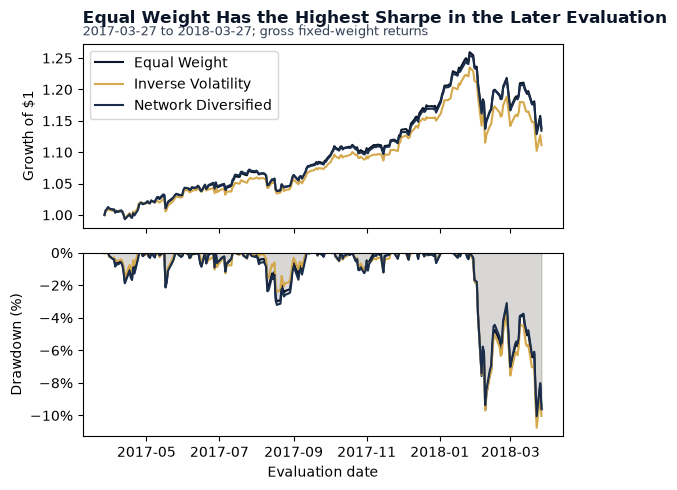

In [29]:
leader = performance.sort("sharpe_ratio", descending=True)["portfolio"][0]
strategy_colors = dict(zip(portfolios, ml4t_palette(3, categorical=True), strict=True))
fig, (ax_growth, ax_drawdown) = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)
for name, metrics in results.items():
    ax_growth.plot(evaluation_index, metrics["growth"], label=name, color=strategy_colors[name])
    ax_drawdown.plot(evaluation_index, metrics["drawdown"], color=strategy_colors[name])
    ax_drawdown.fill_between(
        evaluation_index, metrics["drawdown"], 0, color=strategy_colors[name], alpha=0.08
    )
ax_growth.set_ylabel("Growth of $1")
ax_drawdown.set_ylabel("Drawdown (%)")
ax_drawdown.set_xlabel("Evaluation date")
ax_drawdown.set_ylim(top=0)
format_pct_axis(ax_drawdown)
ax_growth.legend(loc="upper left")
add_message_title(
    ax_growth,
    f"{leader} Has the Highest Sharpe in the Later Evaluation",
    subtitle=f"{evaluation_start} to {evaluation_end}; gross fixed-weight returns",
)
fig.tight_layout()
fig.show()

### Centrality vs Portfolio Weight

The network-diversified rule mechanically underweights high-degree MST nodes.

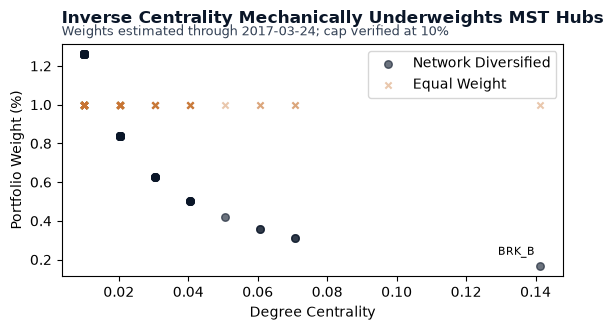

In [30]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.scatter(
    degree_centrality,
    w_network_div * 100,
    alpha=0.6,
    color=COLORS["blue"],
    s=30,
    label="Network Diversified",
)
ax.scatter(
    degree_centrality,
    np.full(n_assets, 100 / n_assets),
    alpha=0.4,
    color=COLORS["copper"],
    s=20,
    marker="x",
    label="Equal Weight",
)
# Label only the highest-degree hub to preserve the pattern without collisions.
hub_idx = int(np.argmax(degree_centrality))
ax.annotate(
    asset_names[hub_idx],
    (degree_centrality[hub_idx], w_network_div[hub_idx] * 100),
    xytext=(-4, 8),
    textcoords="offset points",
    fontsize=8,
    ha="right",
)
ax.set_xlabel("Degree Centrality")
ax.set_ylabel("Portfolio Weight (%)")
add_message_title(
    ax,
    "Inverse Centrality Mechanically Underweights MST Hubs",
    subtitle=f"Weights estimated through {estimation_end}; cap verified at 10%",
)
ax.legend()
fig.tight_layout()
fig.show()

The inverse relationship is a direct consequence of
$w_i \propto 1/(c_i + 0.01)$. It visualizes the rule; it is not independent
evidence that centrality predicts future returns or losses.

## 9. Summary Statistics

In [31]:
summary_stats = {
    "Data source": "Wiki Prices (real data)",
    "Assets analyzed": n_assets,
    "Estimation range": f"{estimation_start} to {estimation_end}",
    "Evaluation range": f"{evaluation_start} to {evaluation_end}",
    "Estimation days": ESTIMATION_DAYS,
    "Evaluation days": EVALUATION_DAYS,
    "MST edges": len(mst_edges),
    "Avg correlation": f"{corr_values.mean():.3f}",
    "Median correlation": f"{np.median(corr_values):.3f}",
    "Network portfolio HHI": f"{np.sum(w_network_div**2):.4f}",
    "Network portfolio Sharpe": f"{results['Network Diversified']['sharpe_ratio']:.2f}",
    "Equal weight Sharpe": f"{results['Equal Weight']['sharpe_ratio']:.2f}",
}

print("NOTEBOOK RESULTS FOR CHAPTER 23.5")

for key, value in summary_stats.items():
    print(f"  {key:35s}: {value}")

NOTEBOOK RESULTS FOR CHAPTER 23.5
  Data source                        : Wiki Prices (real data)
  Assets analyzed                    : 100
  Estimation range                   : 2015-03-26 to 2017-03-24
  Evaluation range                   : 2017-03-27 to 2018-03-27
  Estimation days                    : 504
  Evaluation days                    : 252
  MST edges                          : 99
  Avg correlation                    : 0.335
  Median correlation                 : 0.328
  Network portfolio HHI              : 0.0110
  Network portfolio Sharpe           : 1.19
  Equal weight Sharpe                : 1.21


## 10. Visualization: Estimated MST

Visualize the estimation-window tree while labeling only its most central
nodes so the topology remains legible.

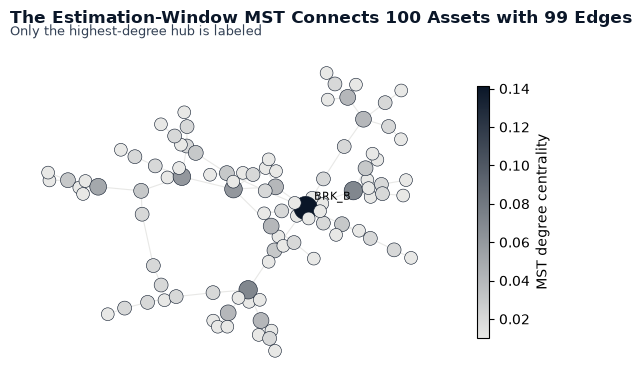

In [32]:
# A seeded spring layout and one hub label expose structure without a label cloud.
positions = nx.spring_layout(mst_graph, seed=SEED, weight="weight")

centrality_cmap = LinearSegmentedColormap.from_list(
    "ml4t_centrality", [COLORS["silver_muted"], COLORS["blue"]]
)
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
nx.draw_networkx_edges(mst_graph, positions, ax=ax, edge_color=COLORS["silver_muted"], width=0.8)
nodes = nx.draw_networkx_nodes(
    mst_graph,
    positions,
    ax=ax,
    node_size=70 + 1_500 * degree_centrality,
    node_color=degree_centrality,
    cmap=centrality_cmap,
    edgecolors=COLORS["blue"],
    linewidths=0.4,
)
hub_x, hub_y = positions[hub_idx]
ax.annotate(
    asset_names[hub_idx],
    (hub_x, hub_y),
    xytext=(6, 6),
    textcoords="offset points",
    fontsize=8,
)
fig.colorbar(nodes, ax=ax, shrink=0.75, label="MST degree centrality")
add_message_title(
    ax,
    f"The Estimation-Window MST Connects {n_assets} Assets with {len(mst_edges)} Edges",
    subtitle="Only the highest-degree hub is labeled",
)
ax.set_axis_off()
fig.tight_layout()
fig.show()

Node size and color encode degree centrality in the estimation-window MST.
Larger nodes are the hubs the inverse-centrality rule mechanically underweights.

## 11. Verification

In [33]:
print("NOTEBOOK EXECUTION COMPLETE")
print("Data: Wiki Prices (real market data)")
print(f"Assets: {n_assets}")
print(f"MST edges: {len(mst_edges)}")
print(f"Centrality range: [{degree_centrality.min():.3f}, {degree_centrality.max():.3f}]")
print(f"Estimation end: {estimation_end}")
print(f"Evaluation start: {evaluation_start}")
print(f"Network portfolio Sharpe: {results['Network Diversified']['sharpe_ratio']:.2f}")
print("Network-based portfolio evaluation complete.")

NOTEBOOK EXECUTION COMPLETE
Data: Wiki Prices (real market data)
Assets: 100
MST edges: 99
Centrality range: [0.010, 0.141]
Estimation end: 2017-03-24
Evaluation start: 2017-03-27
Network portfolio Sharpe: 1.19
Network-based portfolio evaluation complete.


## Key Takeaways

1. **Correlation distance**: Converting correlations to distances via
   $d = \sqrt{2(1 - \rho)}$ satisfies the triangle inequality and enables
   MST construction that reveals hierarchical market structure.
2. **Centrality as a graph property**: Degree, betweenness, and closeness
   centrality describe how connected each asset is in the estimated MST. They
   do not establish causal influence or systemic importance.
3. **Separated evaluation**: Universe membership, the network, volatility,
   and all three weight vectors are fixed before the later 252-session gross
   evaluation. The output tables report the resulting concentration and risk.
4. **Shock sensitivity**: Synchronous diffusion makes the stylized scenario
   order-independent, and portfolio-weighted sensitivity avoids presenting a
   sum of hypothetical asset impacts as a portfolio loss.
5. **MST visualization**: The MST projects the dense correlation matrix into
   a tree that makes cluster structure and bridge nodes visually inspectable.
   This single-window comparison is descriptive, gross of costs, and not a
   claim of future outperformance.

**Next**: See `06_gnn_feature_engineering.py` for using GNN embeddings
derived from these networks as features for ML models.
**Book**: Chapter 23.5 discusses financial network theory and portfolio
applications in detail.